# Qué hace que una voz suene femenina o masculina (más allá del tono)

Análisis exploratorio de las 12 features acústicas que usa el modelo de Crisantemo, sobre los datos reales de entrenamiento (Common Voice 26.0 español mexicano vía Mozilla Data Collective, 5,000 clips).

Contexto: se encontró que el modelo se deja engañar por el tono en voz actuada real (una persona forzando tono agudo o grave sin cambiar su resonancia), incluso después de mezclar datos sintéticos decorrelacionados. Ver `docs/TRAINING_REPRODUCTION.md` secciones 4.3-4.4 y `docs/ARCHITECTURE.md` para el detalle completo de esa investigación. Este notebook busca entender, con los datos que ya tenemos, si hay una forma de entrenar mejor sin necesitar más datos, y si el objetivo es realista con lo que hay disponible.

**Nota metodológica importante:** los 5 casos de prueba reales que se anotan más abajo son grabaciones espontáneas (no un mismo texto/vocal controlada), así que los formantes reportados están promediados sobre lo que sea que se dijo en cada grabación. Los formantes dependen mucho de la vocal específica que se está pronunciando, no solo de la resonancia general de quien habla, así que comparar formantes promedio entre grabaciones con contenido distinto no es una comparación 100% limpia. Vale la pena tenerlo en cuenta al leer las gráficas de abajo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../scripts").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

from acoustic_features import FEATURE_NAMES
from common import PROCESSED_DIR

sns.set_theme(style="whitegrid")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

dfs = []
for split in ("train", "val", "test"):
    d = pd.read_parquet(PROCESSED_DIR / f"features_{split}.parquet")
    d["split"] = split
    dfs.append(d)
df = pd.concat(dfs, ignore_index=True)

df["is_synthetic_decorrelated"] = df["audio_path"].str.contains("synthetic_decorrelated")
df["gender"] = df["label"].map({0: "masculino", 1: "femenino"})

df_real = df[~df["is_synthetic_decorrelated"]].copy()
print(f"Total: {len(df)} filas ({len(df_real)} reales, {len(df) - len(df_real)} sintéticas decorrelacionadas)")
df_real["gender"].value_counts()

Total: 5793 filas (4993 reales, 800 sintéticas decorrelacionadas)


gender
femenino     2500
masculino    2493
Name: count, dtype: int64

## Los 5 casos de prueba reales conocidos

Grabaciones reales de una misma persona, en distintas sesiones de prueba de la app (ver conversación/docs para el contexto completo). Los usamos como puntos de referencia sobre las gráficas de abajo, no como parte del dataset de entrenamiento.

In [2]:
known_cases = pd.DataFrame([
    {"caso": "aguda actuada (score viejo 94.6)", "f0_mean_hz": 321.15, "f1_mean_hz": 410.82, "f2_mean_hz": 1077.28, "f3_mean_hz": 2060.47, "f2_f1_diff_hz": 666.46, "hnr_db": 21.35},
    {"caso": "grave actuada (score viejo 5.9)", "f0_mean_hz": 124.65, "f1_mean_hz": 515.72, "f2_mean_hz": 1500.35, "f3_mean_hz": 2592.01, "f2_f1_diff_hz": 984.63, "hnr_db": 9.78},
    {"caso": "aguda actuada nueva (score 92.8)", "f0_mean_hz": 355.99, "f1_mean_hz": 492.60, "f2_mean_hz": 1005.56, "f3_mean_hz": 1809.39, "f2_f1_diff_hz": 512.96, "hnr_db": 24.76},
    {"caso": "voz normal (score 0.3)", "f0_mean_hz": 113.76, "f1_mean_hz": 434.64, "f2_mean_hz": 1450.65, "f3_mean_hz": 2391.46, "f2_f1_diff_hz": 1016.02, "hnr_db": 10.48},
    {"caso": "voz más grave (score 2.3)", "f0_mean_hz": 103.40, "f1_mean_hz": 426.86, "f2_mean_hz": 1690.46, "f3_mean_hz": 2461.53, "f2_f1_diff_hz": 1263.60, "hnr_db": 11.00},
])
known_cases

,caso,f0_mean_hz,f1_mean_hz,f2_mean_hz,f3_mean_hz,f2_f1_diff_hz,hnr_db
0,aguda actuada (score viejo 94.6),321.15,410.82,1077.28,2060.47,666.46,21.35
1,grave actuada (score viejo 5.9),124.65,515.72,1500.35,2592.01,984.63,9.78
2,aguda actuada nueva (score 92.8),355.99,492.60,1005.56,1809.39,512.96,24.76
3,voz normal (score 0.3),113.76,434.64,1450.65,2391.46,1016.02,10.48
4,voz más grave (score 2.3),103.40,426.86,1690.46,2461.53,1263.60,11.00


## 1. Distribución de cada feature por género (solo datos reales)

In [3]:
summary = df_real.groupby("gender")[FEATURE_NAMES].agg(["mean", "std"])
summary.T

gender                             femenino    masculino
f0_mean_hz                mean   211.811724   135.683719
                          std     27.535142    20.722991
f0_std_hz                 mean    37.091464    29.720198
                          std     15.472524    20.505878
f0_range_semitones        mean    18.595665    17.361738
                          std      7.179808     8.267968
f1_mean_hz                mean   488.357800   455.738122
                          std     51.584222    58.723876
f2_mean_hz                mean  1681.242126  1582.356602
                          std    183.601180   142.516672
f3_mean_hz                mean  2764.885836  2628.921175
                          std    171.751812   156.085668
f2_f1_diff_hz             mean  1192.884326  1126.618480
                          std    187.522711   144.901175
f3_f2_diff_hz             mean  1083.643711  1046.564573
                          std    164.123529   148.542491
jitter_local_pct          mean     2.078789     2.484396
                          std      0.534797     0.629053
shimmer_local_pct         mean     9.431001    12.546910
                          std      2.149676     2.322636
hnr_db                    mean    14.791349    11.143209
                          std      2.602788     2.245561
spectral_centroid_mean_hz mean  1755.874664  1563.367008
                          std    403.139113   390.618142

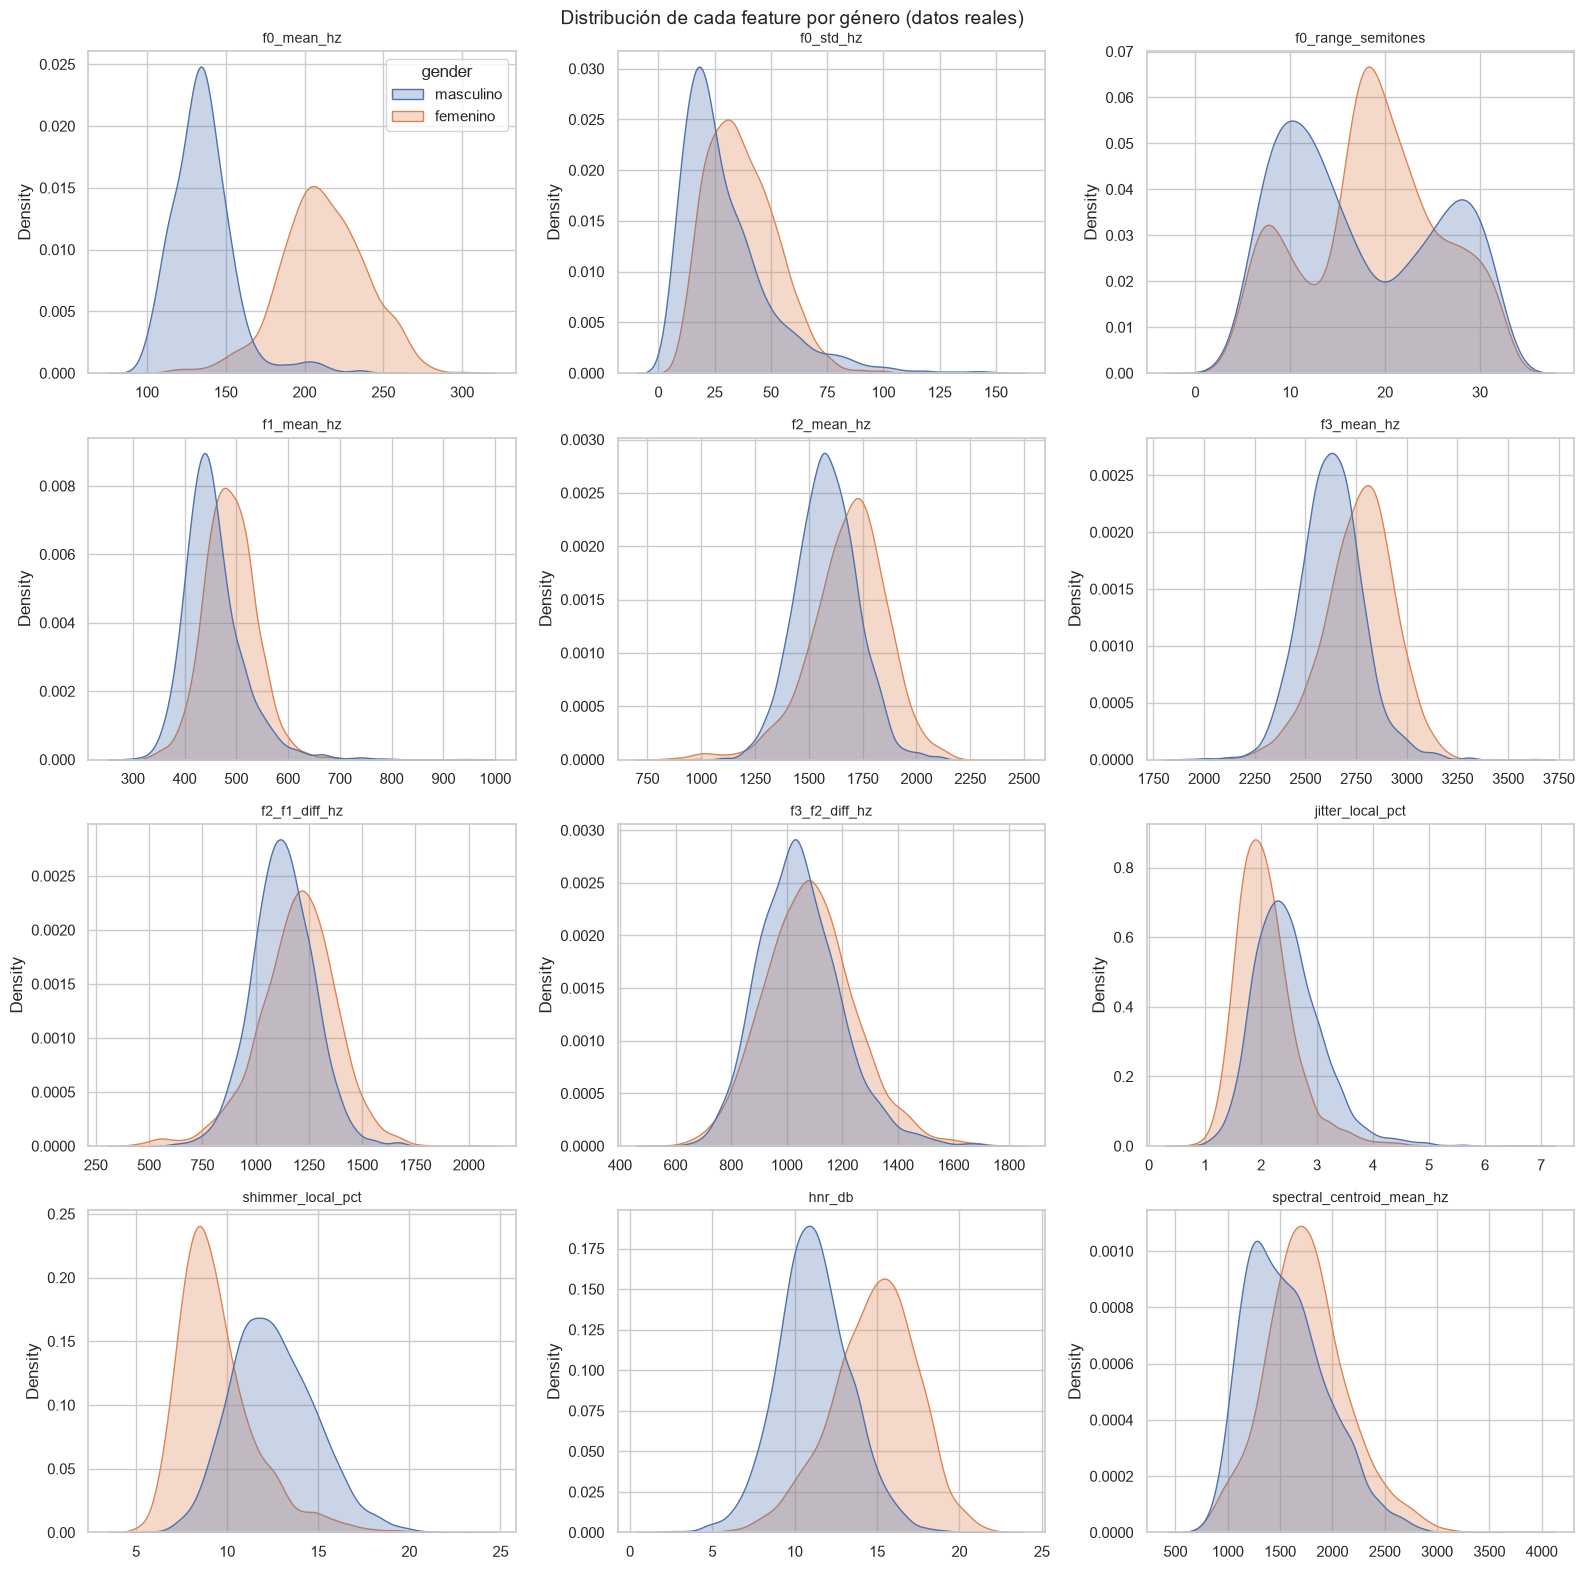

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, name in zip(axes.flat, FEATURE_NAMES):
    sns.kdeplot(data=df_real, x=name, hue="gender", fill=True, alpha=0.3, ax=ax, common_norm=False, legend=(name == FEATURE_NAMES[0]))
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Distribución de cada feature por género (datos reales)", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_distribuciones_por_genero.png", dpi=110)
plt.show()

## 2. ¿Qué tan correlacionados van tono y formantes en voz real?

La hipótesis de `docs/TRAINING_REPRODUCTION.md` sección 4.4 es que en voz real, F0 y los formantes van correlacionados de forma natural, y por eso el modelo aprende a usar el tono como atajo. Esto lo pone a prueba directamente.

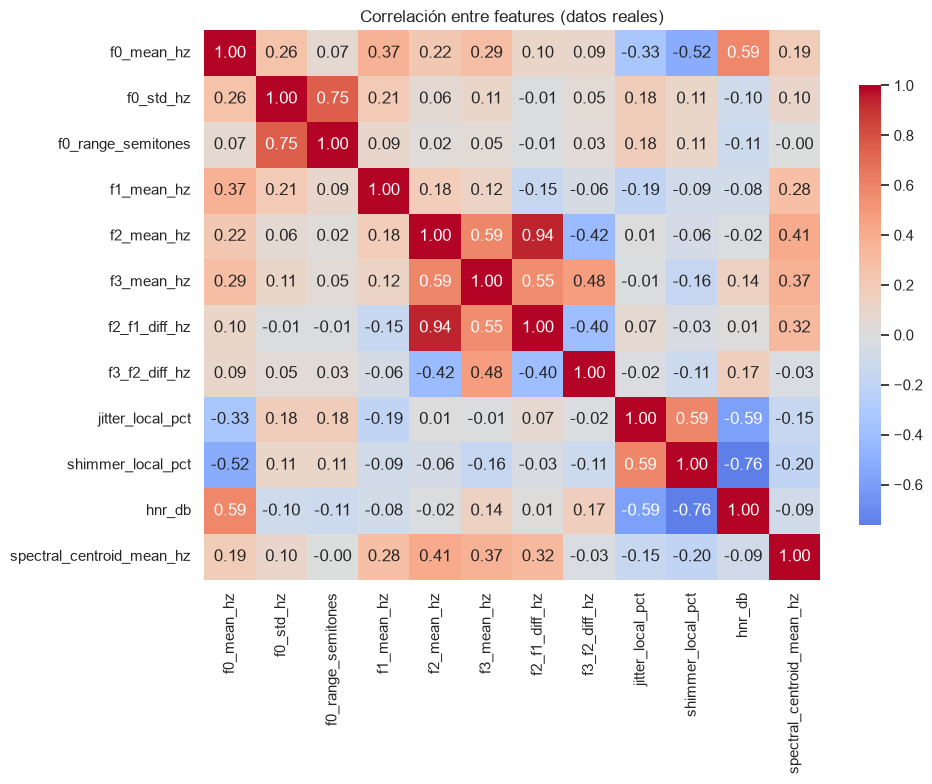

Correlación de f0_mean_hz con cada formante/espaciado:
  f1_mean_hz: r = 0.368
  f2_mean_hz: r = 0.225
  f3_mean_hz: r = 0.295
  f2_f1_diff_hz: r = 0.102
  f3_f2_diff_hz: r = 0.088


In [5]:
corr = df_real[FEATURE_NAMES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlación entre features (datos reales)")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_correlacion_features.png", dpi=110)
plt.show()

print("Correlación de f0_mean_hz con cada formante/espaciado:")
for name in ["f1_mean_hz", "f2_mean_hz", "f3_mean_hz", "f2_f1_diff_hz", "f3_f2_diff_hz"]:
    print(f"  {name}: r = {corr.loc['f0_mean_hz', name]:.3f}")

## 3. Qué tan separable es cada feature por sí sola (AUC univariado)

Si una sola feature ya separa bien las clases, es una señal fuerte. Si el AUC de una feature está cerca de 0.5, esa feature sola no dice casi nada sobre el género en este dataset.

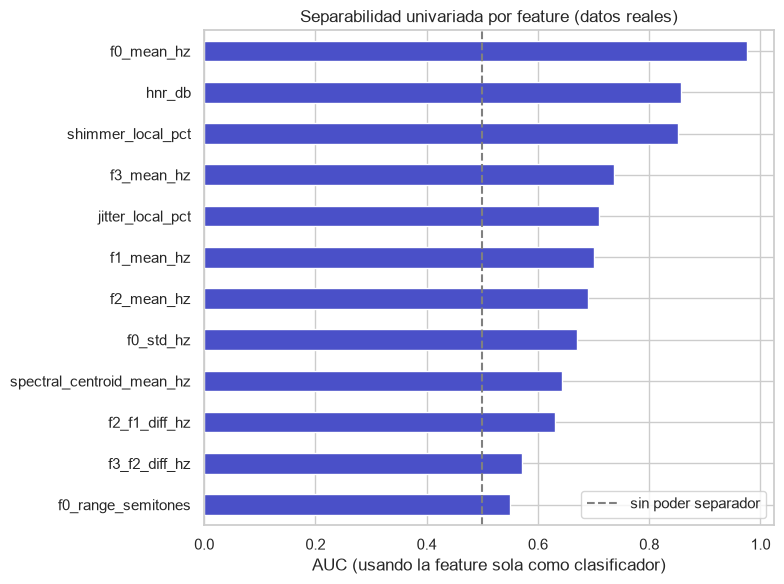

f0_mean_hz                   0.975521
hnr_db                       0.856330
shimmer_local_pct            0.852004
f3_mean_hz                   0.736587
jitter_local_pct             0.708882
f1_mean_hz                   0.699922
f2_mean_hz                   0.689231
f0_std_hz                    0.669512
spectral_centroid_mean_hz    0.643769
f2_f1_diff_hz                0.630324
f3_f2_diff_hz                0.571560
f0_range_semitones           0.550546
dtype: float64

In [6]:
aucs = {}
for name in FEATURE_NAMES:
    auc = roc_auc_score(df_real["label"], df_real[name])
    aucs[name] = max(auc, 1 - auc)  # la dirección no importa aquí, solo qué tan separable es
auc_series = pd.Series(aucs).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
auc_series.plot.barh(ax=ax, color="#4A50C8")
ax.axvline(0.5, color="gray", linestyle="--", label="sin poder separador")
ax.set_xlabel("AUC (usando la feature sola como clasificador)")
ax.set_title("Separabilidad univariada por feature (datos reales)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_auc_univariado.png", dpi=110)
plt.show()
auc_series.sort_values(ascending=False)

## 4. Dónde caen las grabaciones reales de prueba, contra la distribución de entrenamiento

F2-F1 (espaciado de formantes) contra F0, con los 5 casos de prueba reales marcados encima.

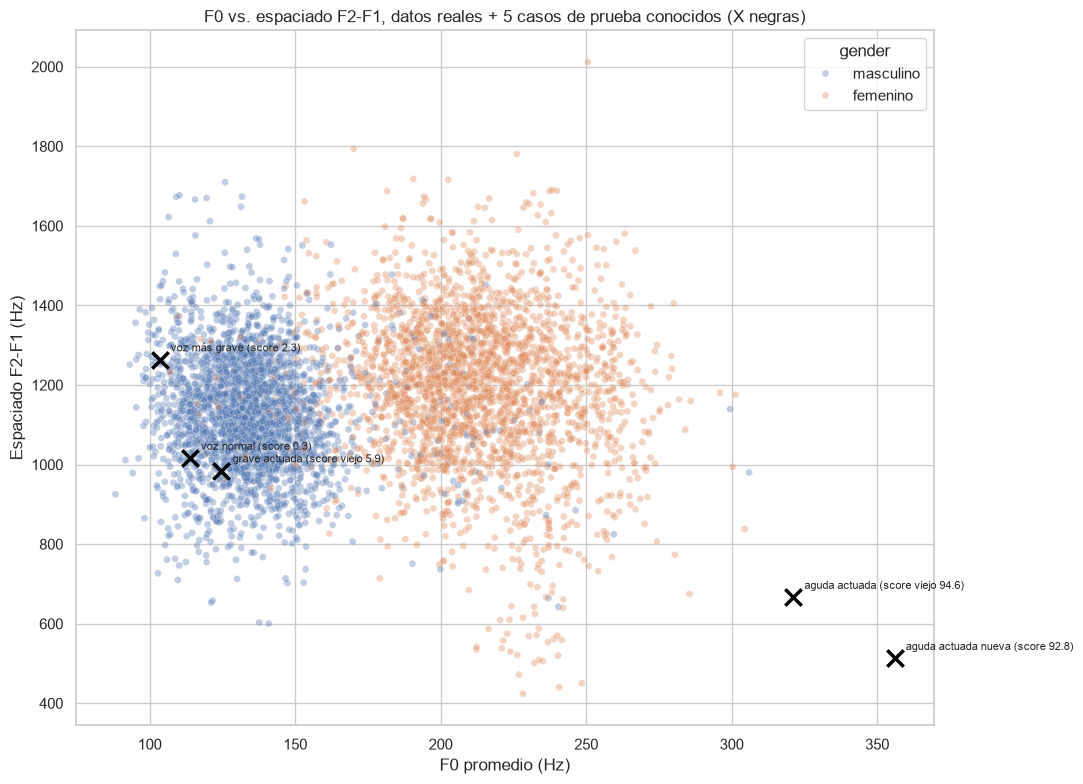

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(data=df_real, x="f0_mean_hz", y="f2_f1_diff_hz", hue="gender", alpha=0.35, s=25, ax=ax)

for _, row in known_cases.iterrows():
    ax.scatter(row["f0_mean_hz"], row["f2_f1_diff_hz"], color="black", marker="x", s=140, linewidths=2.5, zorder=5)
    ax.annotate(row["caso"], (row["f0_mean_hz"], row["f2_f1_diff_hz"]), textcoords="offset points", xytext=(8, 6), fontsize=8, zorder=5)

ax.set_xlabel("F0 promedio (Hz)")
ax.set_ylabel("Espaciado F2-F1 (Hz)")
ax.set_title("F0 vs. espaciado F2-F1, datos reales + 5 casos de prueba conocidos (X negras)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_f0_vs_f2f1_con_casos.png", dpi=110)
plt.show()

## Conclusiones

**1. En este dataset, F0 por sí solo casi separa perfecto las clases (AUC 0.97). Los formantes, por sí solos, apenas separan algo (AUC 0.57-0.73).** No es solo que tono y formantes vayan correlacionados: F0 es sencillamente una señal mucho más limpia y confiable en Common Voice que cualquier feature de resonancia. Las distribuciones de F1/F2/F3/F2-F1/F3-F2 por género se traslapan muchísimo (sección 1); la de F0 casi no se traslapa. Un modelo que optimiza accuracy va a preferir la señal más limpia, eso es exactamente lo que está pasando. Esto corrige la hipótesis original de la sección 4.4 de TRAINING_REPRODUCTION.md (que hablaba de "correlación natural" tono-resonancia): la correlación entre F0 y los formantes es en realidad débil (r=0.10-0.37, ver el heatmap de la sección 2); el problema no es que vayan de la mano, es que los formantes solos casi no dicen nada en este dataset.

**2. Las grabaciones "aguda actuada" están fuera del rango de tono que el modelo vio en entrenamiento.** En la gráfica de la sección 4, los casos de tono agudo (320-356 Hz) caen bien a la derecha de toda la nube de puntos de entrenamiento, que casi no pasa de 300 Hz. El modelo no está clasificando mal ahí por elegir ignorar los formantes: está extrapolando a una zona de tono que nunca vio, y lo único que aprendió a hacer con tonos altos es "más femenino", porque eso es lo único que la señal más fuerte (F0) le enseñó. Esto también explica por qué la aumentación sintética (`_dev_synthetic_decorrelated.py`) no ayudó: sus rangos de F0 (85-140 y 170-260) tampoco llegan a cubrir esa zona de tono extremo.

**3. Respuesta directa a la pregunta que motivó este notebook:** sí parece posible mejorar el modelo sin necesitar más datos reales, pero no solo "prestándole más atención a los formantes" en abstracto. Dos ideas concretas, en orden de qué tan fácil son de intentar:
   - Ampliar `_dev_synthetic_decorrelated.py` para cubrir rangos de F0 más extremos (hasta 350-400+ Hz) cruzados con ambos perfiles de formantes, para que el modelo vea ejemplos de tono muy agudo con formantes masculinos dentro del rango real que la gente termina usando al actuar la voz.
   - Los formantes como se calculan hoy (promedio simple sobre toda la grabación) son una señal débil incluso dentro de los datos reales (AUC 0.57-0.73), no solo para casos actuados. Vale la pena investigar si un mejor cálculo de formantes (normalizado por vocal, o usando la trayectoria en vez de solo el promedio) los haría una señal más fuerte por sí sola, en vez de solo intentar forzar al modelo a usarlos más.
   - Como respaldo si lo anterior no alcanza: una arquitectura híbrida que le garantice un piso de peso a las features de resonancia en el score final, en vez de dejarlo 100% a lo que el modelo decida aprender de los datos disponibles.